In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np



from scipy.stats import normaltest, ks_2samp, levene, ttest_ind

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from zipfile import ZipFile
with ZipFile('archive (10).zip',mode = 'r') as project_data:
    with project_data.open('hospital_deterioration_ml_ready.csv',mode = 'r') as deterioration_ml_ready:
        deterioration_ml_ready = pd.read_csv(deterioration_ml_ready)

In [3]:
deterioration_ml_ready['deterioration_next_12h'] = deterioration_ml_ready['deterioration_next_12h'].astype('category')


In [4]:
deterioration_ml_ready['deterioration_next_12h'] = deterioration_ml_ready['deterioration_next_12h'].astype(int)

look at correlations

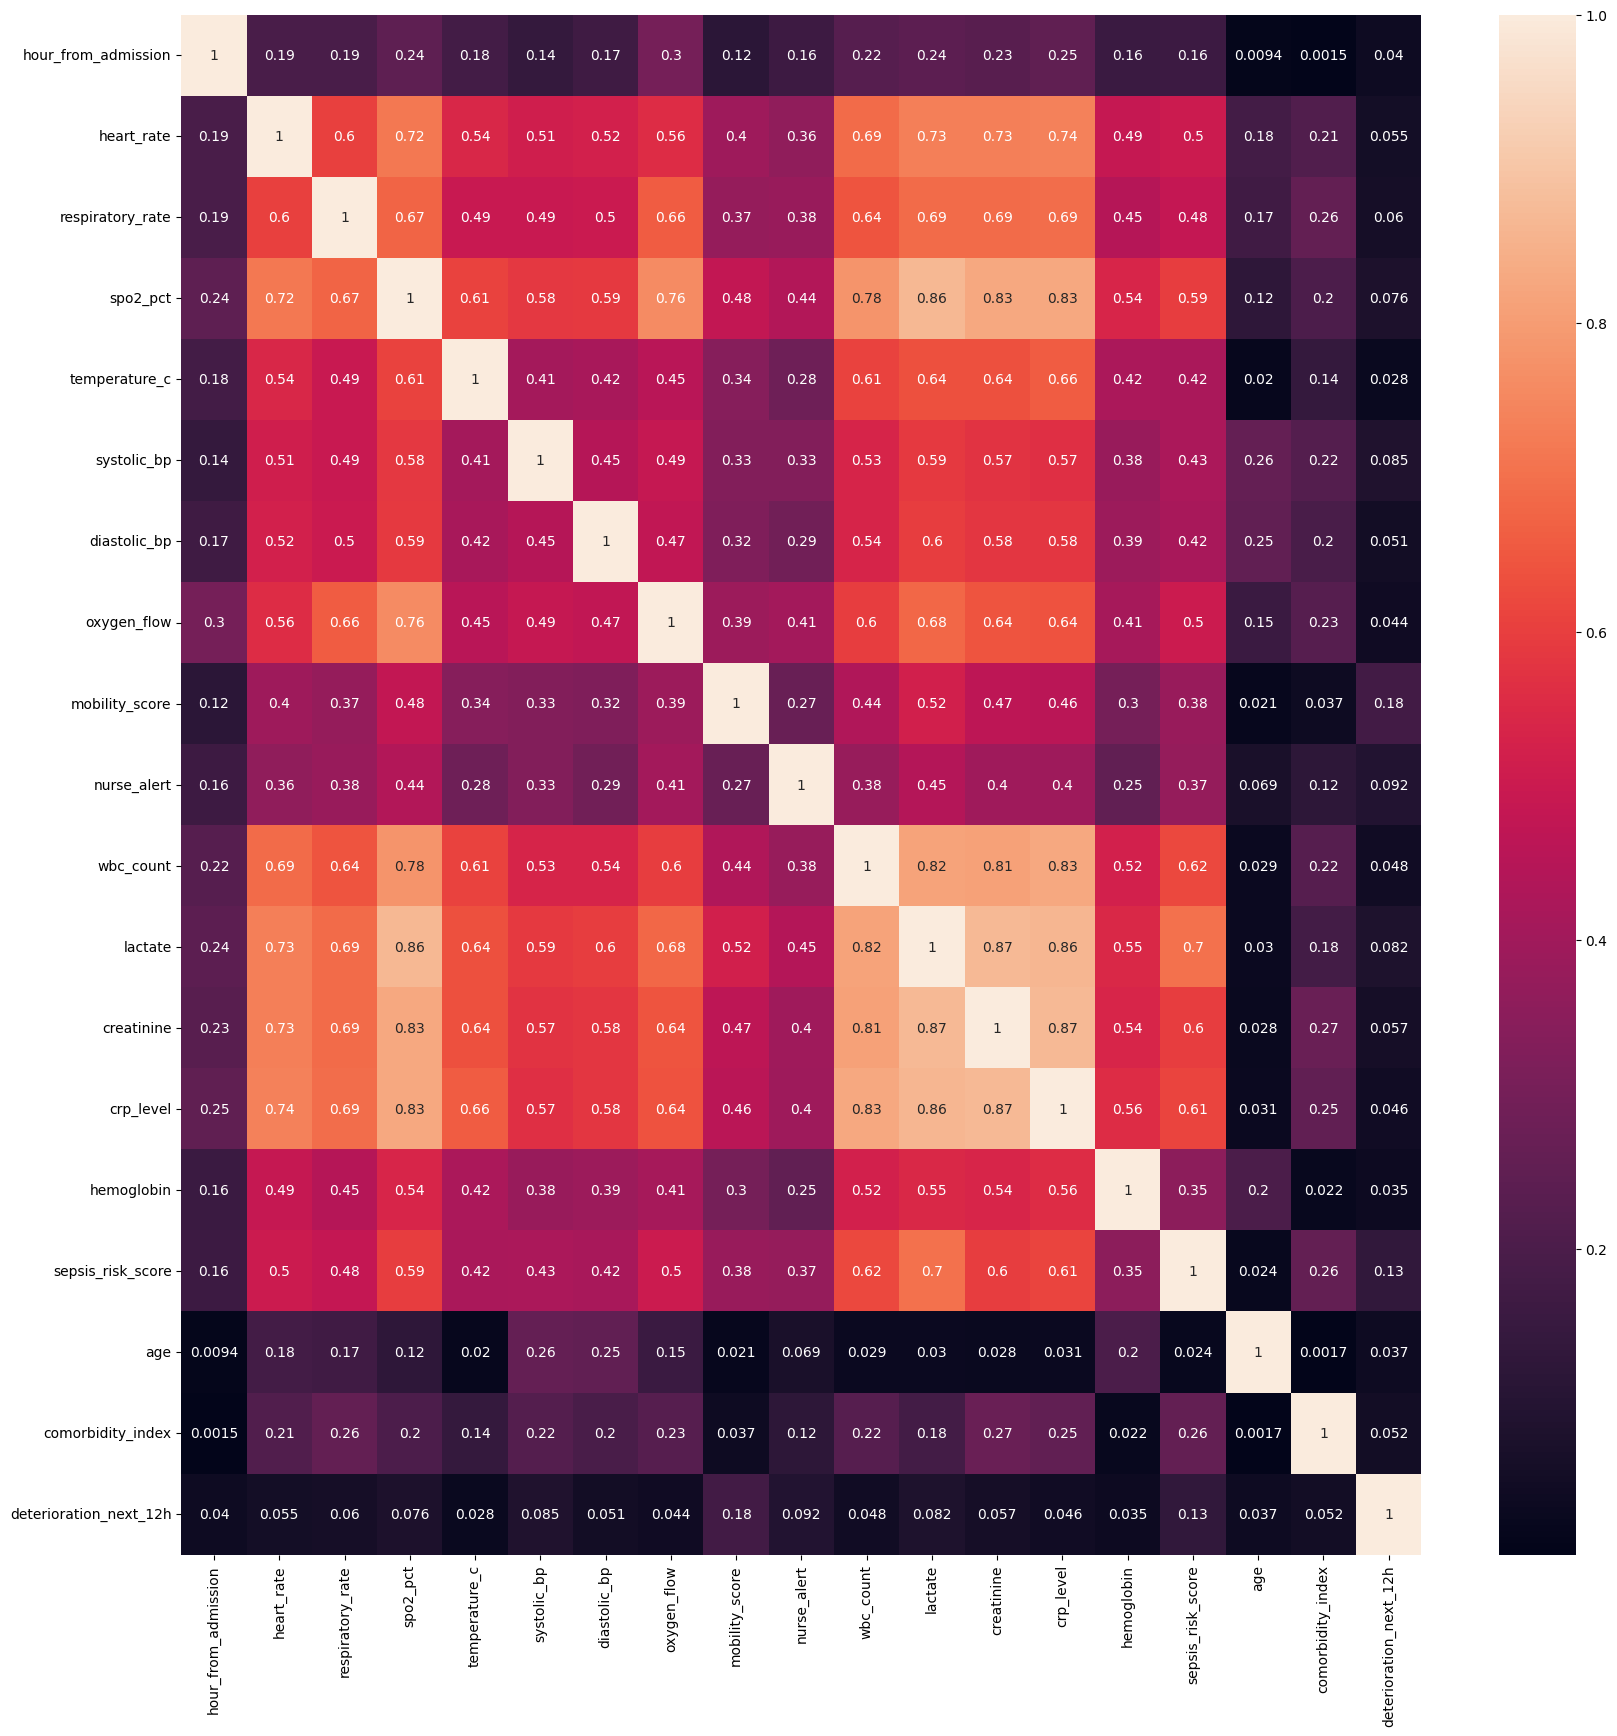

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20,20))
sns.heatmap(abs(deterioration_ml_ready.select_dtypes('number').corr()),annot=True)
plt.show()

### Correlation suggests there is not linear relationship to the target  
it also reveals that `C-reactive protein level (approx. mg/L)` is a very important predictor for many features, but not as evidently for the target

perform t tests, distribution analysis, and visualize numeric columns

In [6]:
columns, whole_normal, negative_normal, positive_normal = [],[],[],[]
t_test, levene_test, ks_test                           = [],[],[]

for col in deterioration_ml_ready.select_dtypes('number').columns:

    # capture column name
    columns.append(col)

    whole = deterioration_ml_ready[col]
    negative = deterioration_ml_ready.loc[deterioration_ml_ready['deterioration_next_12h']==0][col]
    positive = deterioration_ml_ready.loc[deterioration_ml_ready['deterioration_next_12h']==1][col]

    whole_normal.append(normaltest(whole)[1])
    negative_normal.append(normaltest(negative)[1])
    positive_normal.append(normaltest(positive)[1])
    
    t_test.append(ttest_ind(positive,
                              negative,
                              nan_policy='raise')[1])

    levene_test.append(levene(negative,positive)[1])

    ks_test.append(ks_2samp(negative,positive)[1])


dist_df = pd.DataFrame({'column':columns, 
                        'normaltest':whole_normal, 
                        '0-normaltest':negative_normal, 
                        '1-normaltest':positive_normal,
                        't_test':t_test, 
                        'levene':levene_test, 
                        'ks_test':ks_test 
})

/home/lelandmesford/Projects/Consumer_Habits/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1677: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  b2 = skew(a, axis, _no_deco=True)
/home/lelandmesford/Projects/Consumer_Habits/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1778: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  b2 = kurtosis(a, axis, fisher=False, _no_deco=True)
/home/lelandmesford/Projects/Consumer_Habits/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/home/lelandmes

In [ ]:
display(round(dist_df.set_index('column'),3))


,normaltest,0-normaltest,1-normaltest,t_test,levene,ks_test
column,,,,,,
hour_from_admission,0.0,0.0,0.000,0.0,0.000,0.0
heart_rate,0.0,0.0,0.000,0.0,0.000,0.0
respiratory_rate,0.0,0.0,0.000,0.0,0.000,0.0
spo2_pct,0.0,0.0,0.000,0.0,0.000,0.0
temperature_c,0.0,0.0,0.000,0.0,0.000,0.0
systolic_bp,0.0,0.0,0.000,0.0,0.000,0.0
diastolic_bp,0.0,0.0,0.119,0.0,0.000,0.0
oxygen_flow,0.0,0.0,0.000,0.0,0.000,0.0
mobility_score,0.0,0.0,0.000,0.0,0.000,0.0


Test results indicate that there are statistically significant differences between negative `deterioration_next_12h` and positive  

In [8]:
plot_data = deterioration_ml_ready.select_dtypes('number').copy()
plot_data = plot_data[[i for i in plot_data.columns if i!= 'deterioration_next_12h']].stack().to_frame()
plot_data['original_index'] = plot_data.index.get_level_values(0)
plot_data.index = plot_data.index.get_level_values(1)
plot_data = pd.merge(plot_data, 
                     deterioration_ml_ready['deterioration_next_12h'],
                     left_on='original_index',
                     right_index=True)
plot_data.columns = ['val','index','deterioration_next_12h']

In [9]:
x = plot_data.index
y = plot_data['val']
hue = 'deterioration_next_12h'


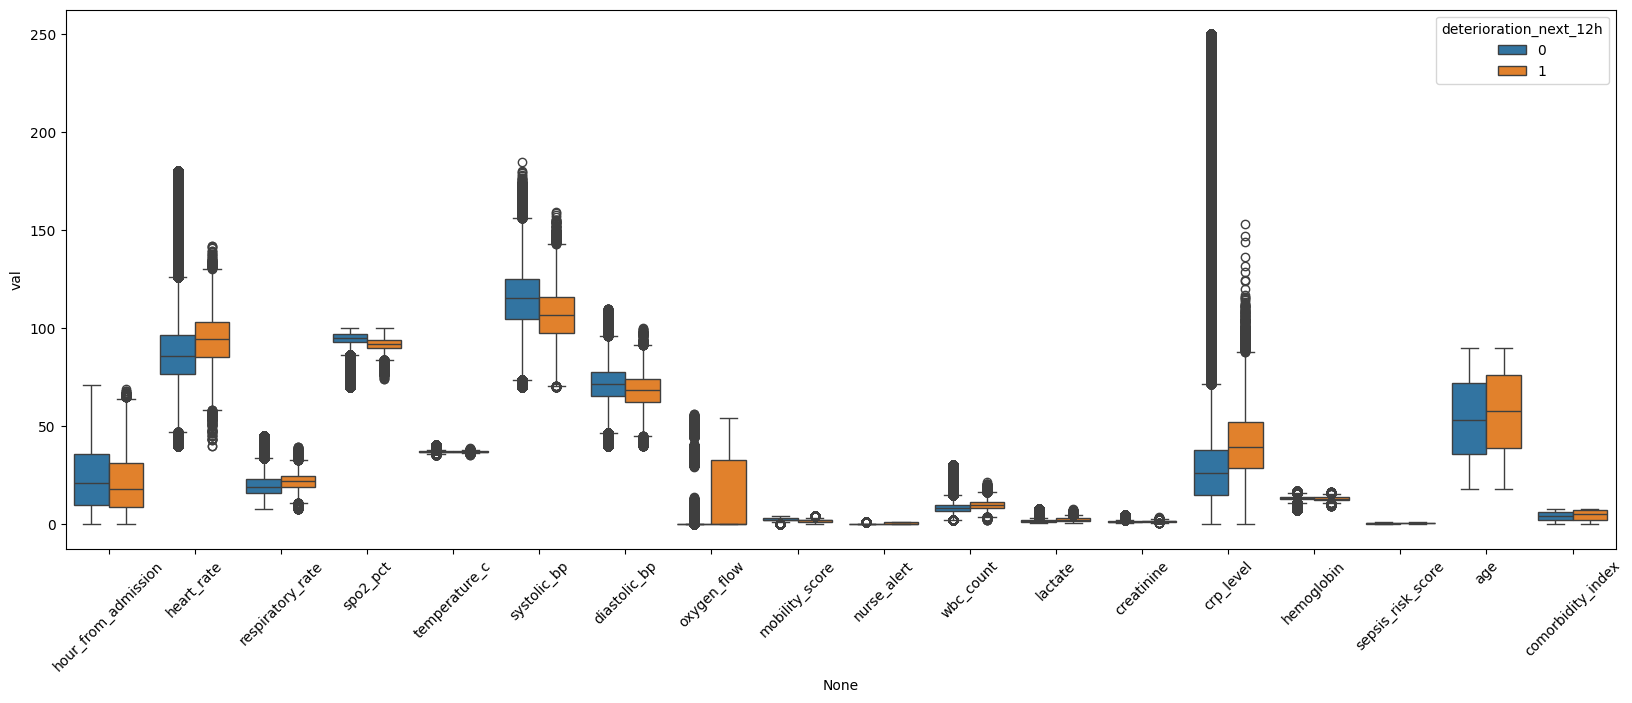

In [10]:
plt.figure(figsize=(20,7))
sns.boxplot(data=plot_data,
              x   = x,
              y   = y,
              hue = hue
              )
plt.tick_params(axis='x',rotation=45)
plt.show()

> in general: plots confirm the differences

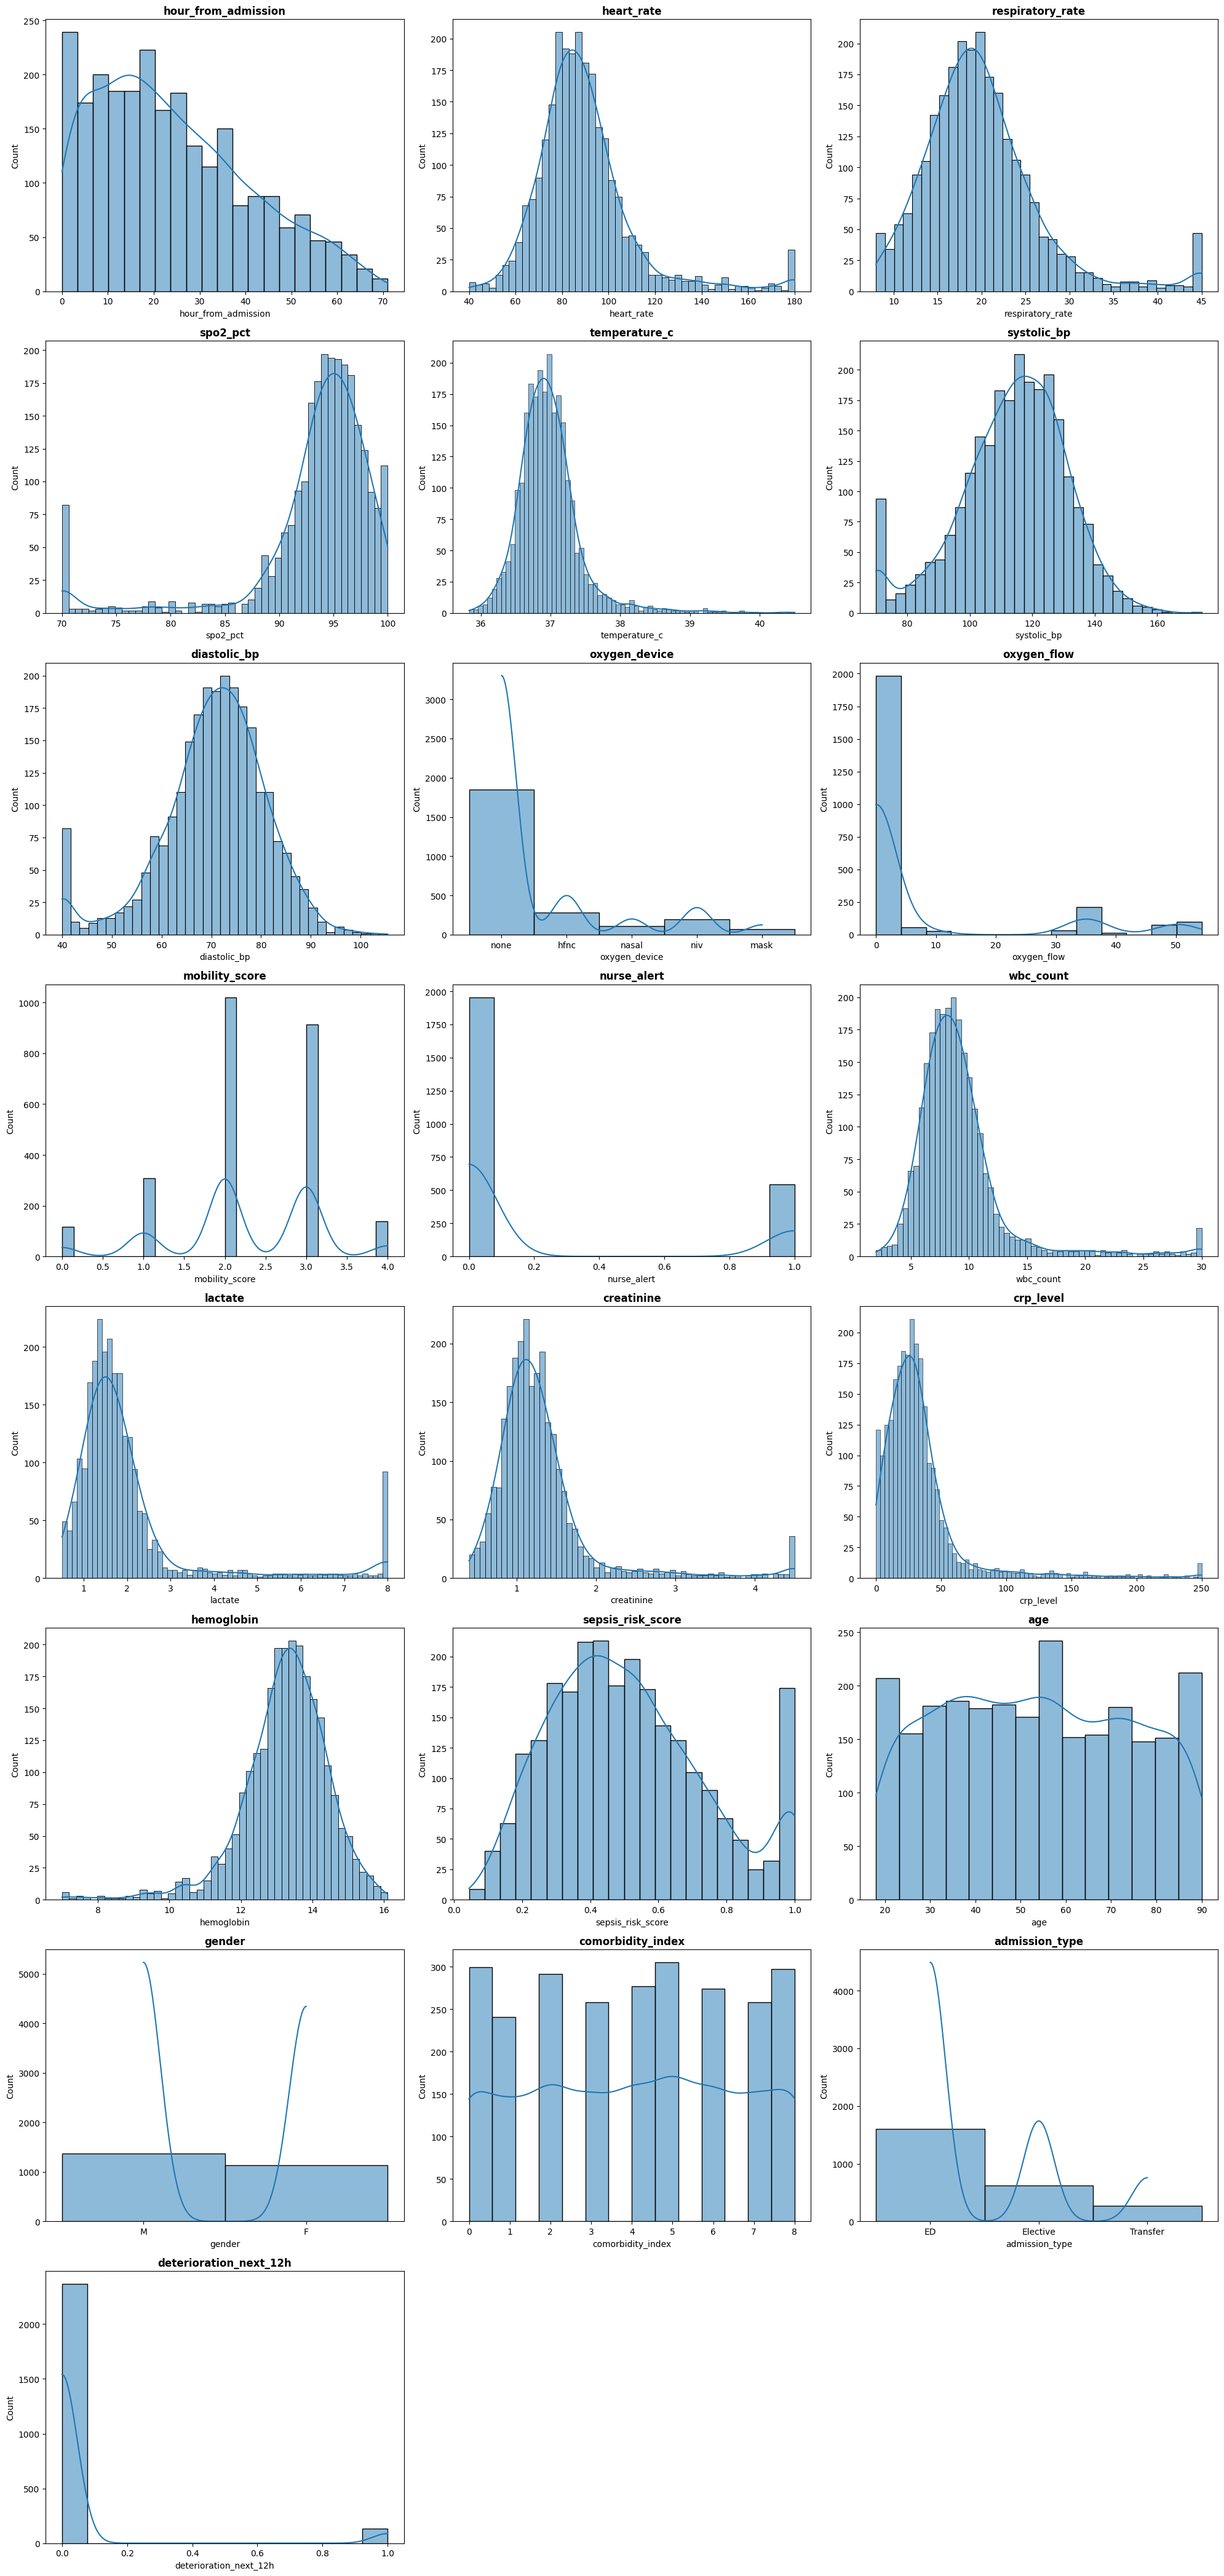

In [11]:
# Method 1: Flatten the 2D array of axes to iterate easily
n_plots = len(deterioration_ml_ready.columns)
n_cols  = 3
n_rows  = int(np.ceil(n_plots/n_cols))
columns = deterioration_ml_ready.columns

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, 2+(n_rows*5)))
# Flatten makes it easy to iterate: axes is 2D (n_rows, n_cols), flatten makes it 1D
axes_flat = axes.flatten()

for i, col in enumerate(columns):
    if i < len(axes_flat):  # Make sure we don't exceed available subplots
        sns.histplot(x=deterioration_ml_ready[col].sample(min(2500, len(deterioration_ml_ready))), 
                     ax=axes_flat[i], kde=True)  # Use ax= not axis=
        axes_flat[i].set_title(col, fontsize=12, fontweight='bold')
        axes_flat[i].set_xlabel(col)

# Hide unused subplots
for i in range(n_plots, len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, MaxAbsScaler, PowerTransformer, FunctionTransformer, QuantileTransformer

target_col = 'deterioration_next_12h'
numeric_cols = [col for col in deterioration_ml_ready.select_dtypes('number').columns if col != target_col]
candidate_specs = [
    ('robust_scaler', lambda: RobustScaler()),
    ('standard_scaler', lambda: StandardScaler()),
    ('minmax_scaler', lambda: MinMaxScaler()),
    ('maxabs_scaler', lambda: MaxAbsScaler()),
    ('yeo_johnson', lambda: PowerTransformer(method='yeo-johnson', standardize=True)),
    ('quantile_normal', lambda: QuantileTransformer(output_distribution='normal', random_state=42, n_quantiles=min(1000, len(deterioration_ml_ready)))),
    ('log1p', lambda: FunctionTransformer(np.log1p, feature_names_out='one-to-one', validate=False)),
    ('sqrt', lambda: FunctionTransformer(np.sqrt, feature_names_out='one-to-one', validate=False)),
    ('signed_sqrt', lambda: FunctionTransformer(lambda x: np.sign(x) * np.sqrt(np.abs(x)), feature_names_out='one-to-one', validate=False)),
    ('identity', lambda: FunctionTransformer(lambda x: x, feature_names_out='one-to-one', validate=False)),
]

def _safe_transform_candidate(column_values, scaler_name, scaler_factory):
    values = column_values.to_numpy(dtype=float).reshape(-1, 1)
    finite_mask = np.isfinite(values[:, 0])
    values = values[finite_mask]
    if values.size == 0 or np.unique(values).size <= 1:
        return {
            'scaler': scaler_name,
            'statistic': np.nan,
            'pvalue': np.nan,
            'reason': 'constant_or_empty',
            'transformed': pd.Series(index=column_values.index, dtype=float),
        }

    is_nonnegative = np.nanmin(values) >= 0
    if scaler_name == 'log1p' and not is_nonnegative:
        return {
            'scaler': scaler_name,
            'statistic': np.nan,
            'pvalue': np.nan,
            'reason': 'skipped_negative_values',
            'transformed': pd.Series(index=column_values.index, dtype=float),
        }
    if scaler_name == 'sqrt' and not is_nonnegative:
        return {
            'scaler': scaler_name,
            'statistic': np.nan,
            'pvalue': np.nan,
            'reason': 'skipped_negative_values',
            'transformed': pd.Series(index=column_values.index, dtype=float),
        }

    try:
        scaler = scaler_factory()
        transformed = scaler.fit_transform(values)
        transformed = np.asarray(transformed, dtype=float).reshape(-1)
        transformed = transformed[np.isfinite(transformed)]
        if transformed.size < 8 or np.unique(transformed).size <= 1:
            statistic = np.nan
            pvalue = np.nan
            reason = 'insufficient_values_for_normaltest'
        else:
            statistic, pvalue = normaltest(transformed)
            statistic = float(statistic)
            pvalue = float(pvalue)
            reason = 'normaltest'

        transformed_series = pd.Series(index=column_values.index, dtype=float)
        transformed_series.loc[column_values.index[finite_mask]] = transformed
        return {
            'scaler': scaler_name,
            'statistic': statistic,
            'pvalue': pvalue,
            'reason': reason,
            'transformed': transformed_series,
        }
    except Exception as exc:
        return {
            'scaler': scaler_name,
            'statistic': np.nan,
            'pvalue': np.nan,
            'reason': f'transform_failed: {type(exc).__name__}',
            'transformed': pd.Series(index=column_values.index, dtype=float),
        }

best_scaler_rows = []
best_scaled_columns = {}
candidate_scores = []

for col in numeric_cols:
    column_results = []
    series = deterioration_ml_ready[col].dropna()
    for scaler_name, scaler_factory in candidate_specs:
        result = _safe_transform_candidate(series, scaler_name, scaler_factory)
        result['column'] = col
        column_results.append(result)

    valid_results = [item for item in column_results if pd.notna(item['pvalue'])]
    if valid_results:
        best_result = sorted(valid_results, key=lambda item: (-item['pvalue'], item['scaler']))[0]
    else:
        best_result = next(item for item in column_results if item['scaler'] == 'identity')

    best_scaler_rows.append({
        'column': col,
        'best_scaler': best_result['scaler'],
        'best_normaltest_statistic': best_result['statistic'],
        'best_normaltest_pvalue': best_result['pvalue'],
        'reason': best_result['reason'],
    })
    best_scaled_columns[col] = best_result['transformed']
    for item in column_results:
        candidate_scores.append({
            'column': col,
            'scaler': item['scaler'],
            'normaltest_statistic': item['statistic'],
            'normaltest_pvalue': item['pvalue'],
            'reason': item['reason'],
        })

best_scaler_df = pd.DataFrame(best_scaler_rows).sort_values(['best_normaltest_pvalue', 'column'], ascending=[False, True]).reset_index(drop=True)
candidate_scores_df = pd.DataFrame(candidate_scores)

print('Best scaler by column:')
display(best_scaler_df)
print('All candidate scaler scores:')
display(candidate_scores_df.sort_values(['column', 'normaltest_pvalue'], ascending=[True, False]))

best_scaled_df = deterioration_ml_ready.copy()
for col, scaled_series in best_scaled_columns.items():
    best_scaled_df[col] = scaled_series


best_scaled_df

Best scaler by column:


,column,best_scaler,best_normaltest_statistic,best_normaltest_pvalue,reason
0,temperature_c,quantile_normal,43.126179,4.317866e-10,normaltest
1,systolic_bp,yeo_johnson,599.227839,7.574048e-131,normaltest
2,sepsis_risk_score,quantile_normal,983.954486,2.172692e-214,normaltest
3,age,identity,319644.506910,0.000000e+00,normaltest
4,comorbidity_index,identity,599627.268702,0.000000e+00,normaltest
5,creatinine,identity,248027.100074,0.000000e+00,normaltest
6,crp_level,identity,298830.260091,0.000000e+00,normaltest
7,diastolic_bp,identity,30704.118569,0.000000e+00,normaltest
8,heart_rate,identity,150880.263674,0.000000e+00,normaltest
9,hemoglobin,identity,81861.551438,0.000000e+00,normaltest


All candidate scaler scores:


,column,scaler,normaltest_statistic,normaltest_pvalue,reason
160,age,robust_scaler,319644.506910,0.0,normaltest
161,age,standard_scaler,319644.506910,0.0,normaltest
162,age,minmax_scaler,319644.506910,0.0,normaltest
163,age,maxabs_scaler,319644.506910,0.0,normaltest
164,age,yeo_johnson,236673.066472,0.0,normaltest
...,...,...,...,...,...
105,wbc_count,quantile_normal,67980.351603,0.0,normaltest
106,wbc_count,log1p,51109.189842,0.0,normaltest
107,wbc_count,sqrt,134514.625658,0.0,normaltest
108,wbc_count,signed_sqrt,134514.625658,0.0,normaltest


,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,mobility_score,...,lactate,creatinine,crp_level,hemoglobin,sepsis_risk_score,age,gender,comorbidity_index,admission_type,deterioration_next_12h
0,0.0,68.58,14.47,96.52,0.743040,-0.338364,78.43,none,0.0,2.0,...,1.28,1.27,10.66,13.55,-1.022210,24.0,M,2.0,Elective,0
1,1.0,67.03,13.87,94.94,0.907080,-0.174686,79.14,none,0.0,3.0,...,1.18,1.22,11.94,13.65,-0.608567,24.0,M,2.0,Elective,0
2,2.0,69.05,14.63,94.45,0.995858,-0.189515,78.86,none,0.0,2.0,...,1.21,1.25,10.24,13.69,-1.730030,24.0,M,2.0,Elective,0
3,3.0,69.07,14.42,95.16,0.951518,-0.236753,76.79,none,0.0,2.0,...,1.13,1.24,10.72,13.61,-1.494450,24.0,M,2.0,Elective,0
4,4.0,73.35,15.62,95.83,0.817902,-0.254383,75.47,none,0.0,3.0,...,1.20,1.21,11.46,13.49,-0.800673,24.0,M,2.0,Elective,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
417861,24.0,89.82,20.65,95.46,-1.517545,0.465335,70.56,none,0.0,4.0,...,1.83,1.36,14.76,13.38,-0.334755,62.0,F,1.0,ED,0
417862,25.0,92.38,20.80,95.30,-1.439001,0.597632,72.08,none,0.0,1.0,...,1.71,1.35,14.75,13.29,-0.052621,62.0,F,1.0,ED,0
417863,26.0,94.65,21.43,94.39,-1.517545,0.565506,71.41,none,0.0,1.0,...,1.75,1.40,12.76,13.16,-1.470846,62.0,F,1.0,ED,0
417864,27.0,95.72,21.23,94.90,-1.439001,0.408638,70.60,none,0.0,3.0,...,1.64,1.39,14.96,13.14,0.234528,62.0,F,1.0,ED,0


metrics indicate that scaling did not improve normality by much

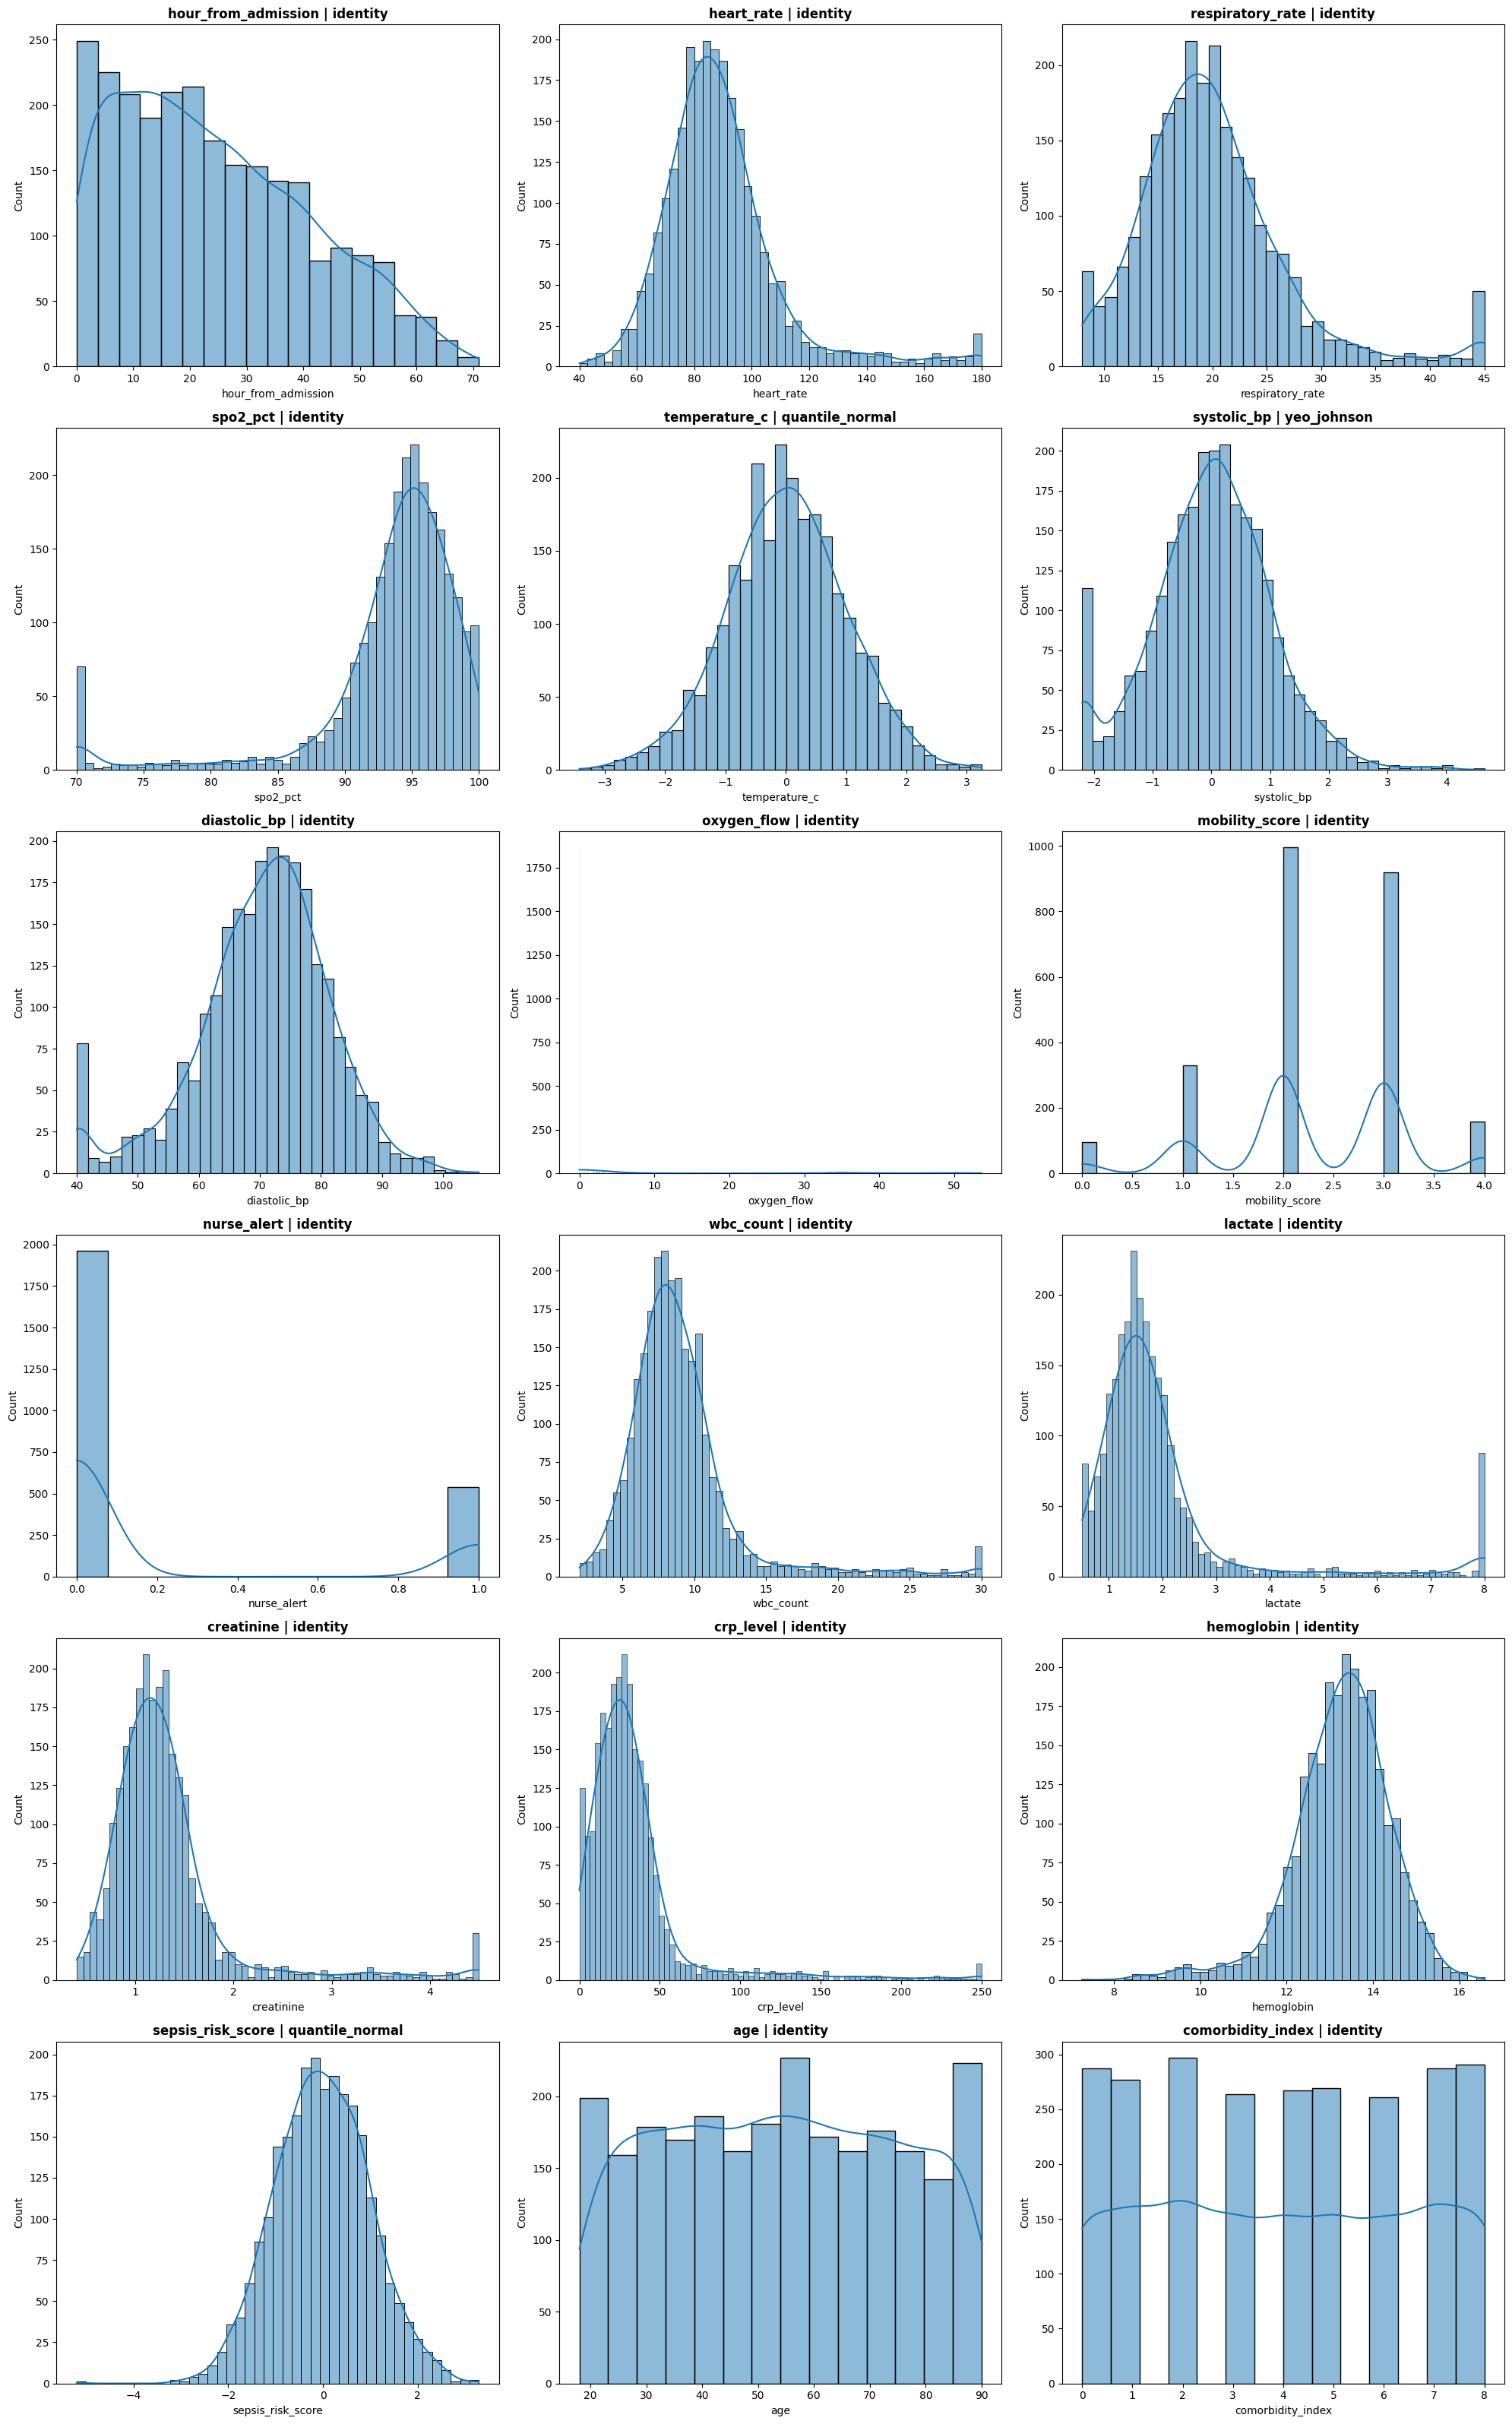

In [13]:
n_plots = len(numeric_cols)
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, 2 + (n_rows * 5)))
axes_flat = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i < len(axes_flat):
        sns.histplot(x=best_scaled_df[col].dropna().sample(min(2500, best_scaled_df[col].dropna().shape[0]), random_state=42), ax=axes_flat[i], kde=True)
        axes_flat[i].set_title(f'{col} | {best_scaler_df.loc[best_scaler_df["column"] == col, "best_scaler"].iloc[0]}', fontsize=12, fontweight='bold')
        axes_flat[i].set_xlabel(col)

for i in range(n_plots, len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.tight_layout()
plt.show()

The bigger problem seems to be outliers. 